In [ ]:
study_name = None
study_id = None
model_id = None
study_dir = None

In [2]:
import mutopia.analysis as mu
import mutopia.plot.track_plot as tr
import matplotlib.pyplot as plt
import seaborn as sns
import os

study_id = f"{study_id:02d}"
def output_path(*paths: str):
    return os.path.join("analyses", str(study_name), study_id, str(model_id), *paths)

output_dir = output_path("")
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

/n/data1/hms/dbmi/park/ctDNA_loci_project/locusregression/shared_envs/mutopia-official/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = mu.load_model(f"studies/{study_name}/{study_id}/trial={model_id}.pkl")
data = mu.gt.lazy_load(f"gtensors/{study_name}.nc")

INFO     Mutopia JIT-compiling model operations ...


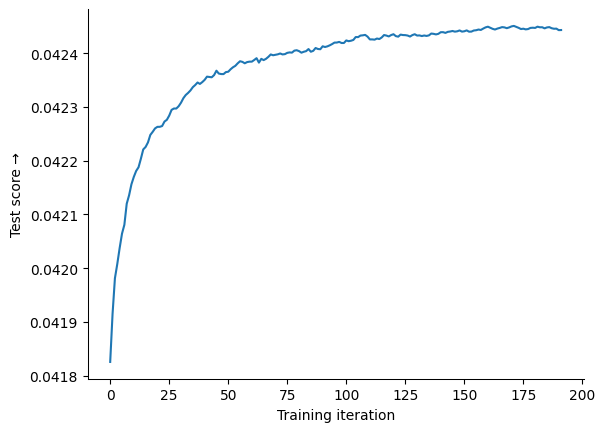

In [4]:
ax=sns.lineplot(model.test_scores_[3:])
ax.set(xlabel="Training iteration", ylabel="Test score \u2192")
sns.despine()

In [ ]:
data = model.annot_contributions(data) # Annotate the contributions using the entire dataset!
data = mu.gt.slice_regions(data, "chr2")
data = model.annot_component_distributions(data)
data = model.annot_marginal_prediction(data)
data = model.annot_components(data)
#data = model.annot_SHAP_values(data, 0, threads=5)
data = mu.gt.annot_empirical_marginal(data)

INFO     Mutopia Found 31651/360336 regions matching query.
INFO     Mutopia Setting up dataset state ...
INFO     Mutopia Done ...
INFO     Mutopia Setting model to prediction mode.
Estimating contributions: 100%|███████████████████████████████████| 753/753 [00:19<00:00, 38.08it/s]
INFO     Mutopia Added key to dataset: "contributions"
INFO     Mutopia Added key: "component_distributions"
INFO     Mutopia Added key: "component_distributions_locus"
INFO     Mutopia Added key: "predicted_marginal"
INFO     Mutopia Added key: "predicted_marginal_locus"
INFO     Mutopia Added keys to dataset: Spectra/spectra, Spectra/interactions, Spectra/shared_effects
Reducing samples: 100%|██████████| 752/752 [00:34<00:00, 21.83it/s]
INFO     Mutopia Added key: "empirical_marginal"
INFO     Mutopia Added key: "empirical_marginal_locus"


mu.gt.write_dataset(data, output_path("annotated_data.nc"), write_samples=False)

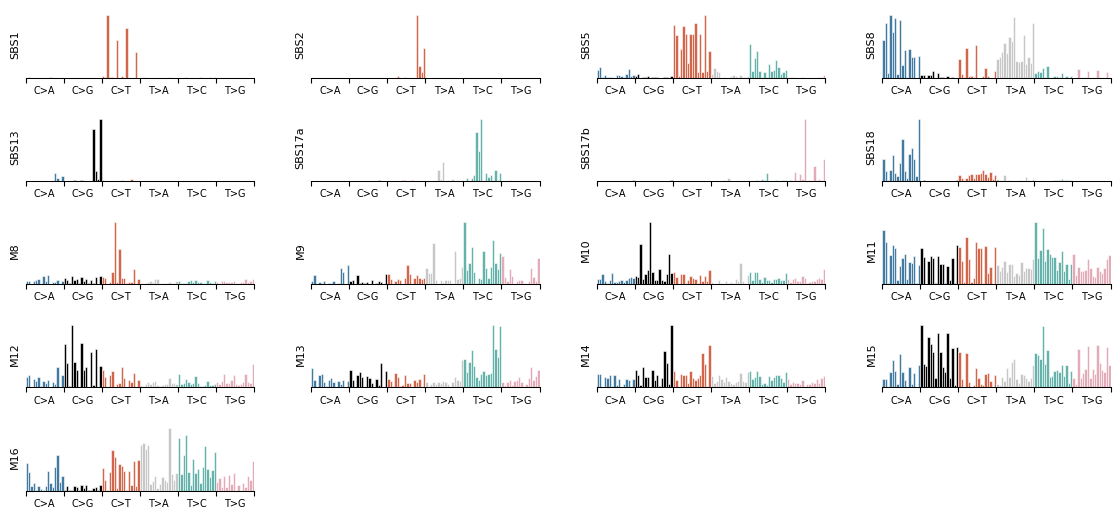

In [7]:
mu.pl.plot_signature_panel(data)

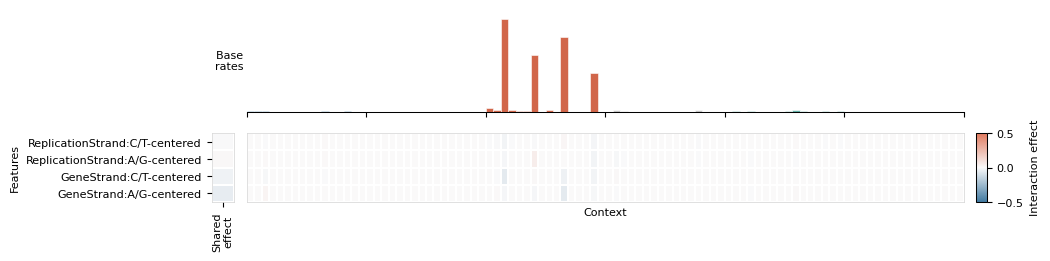

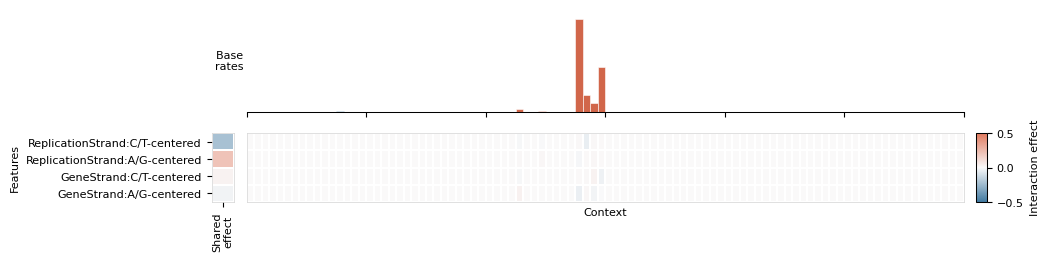

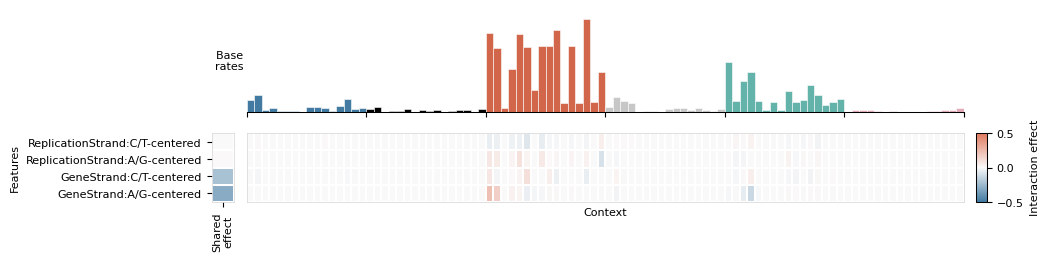

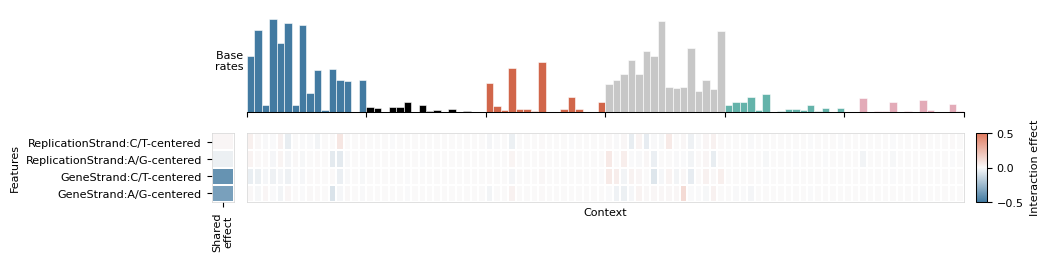

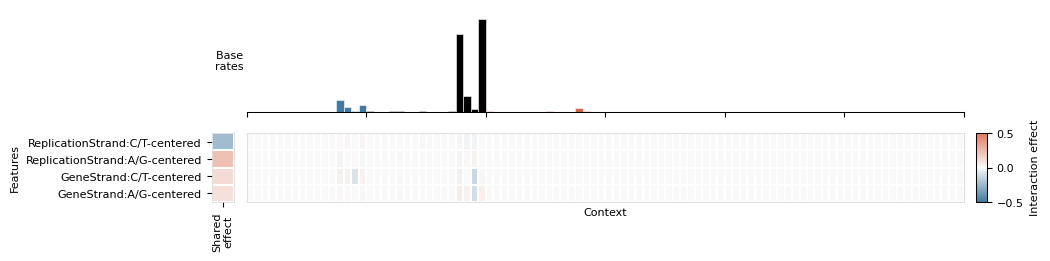

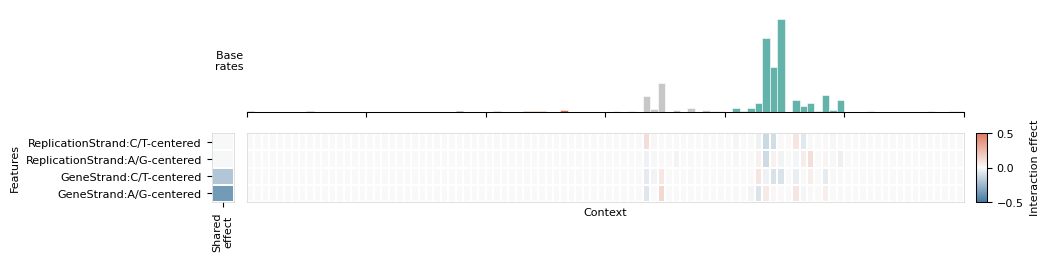

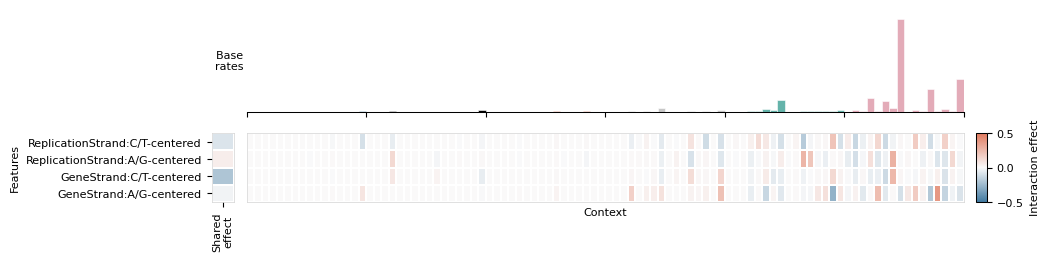

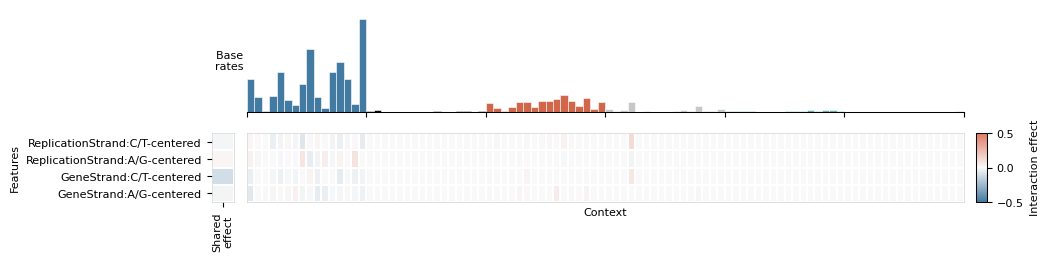

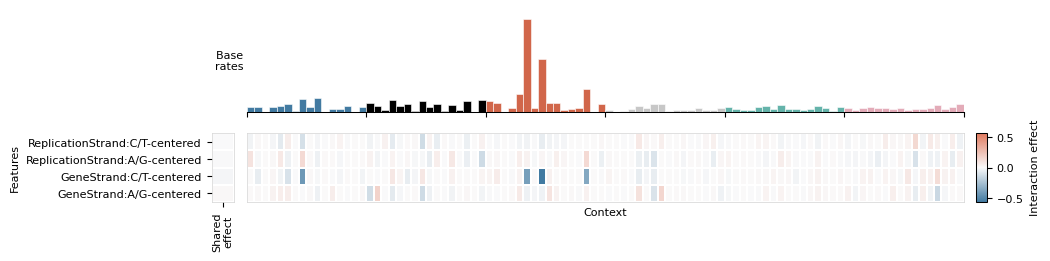

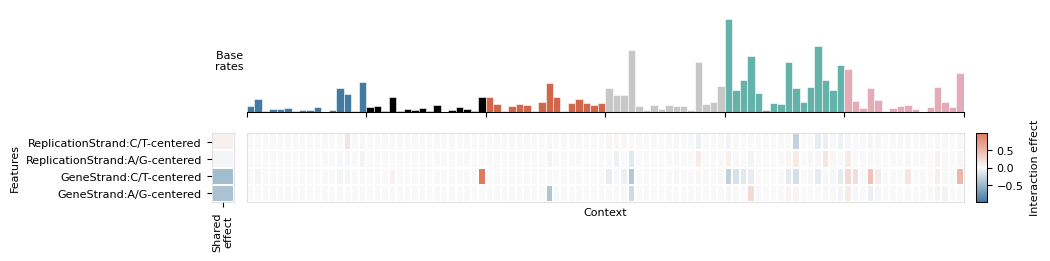

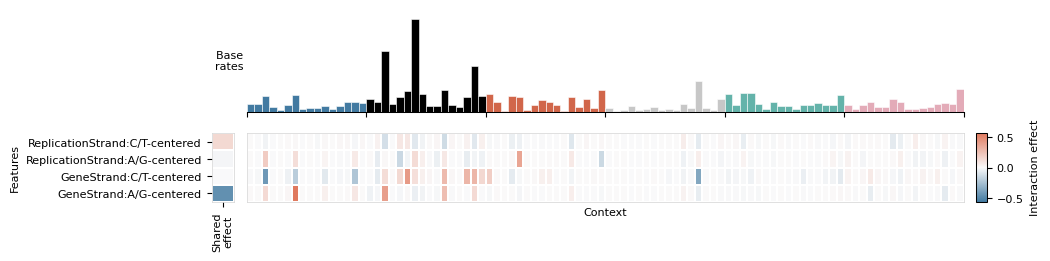

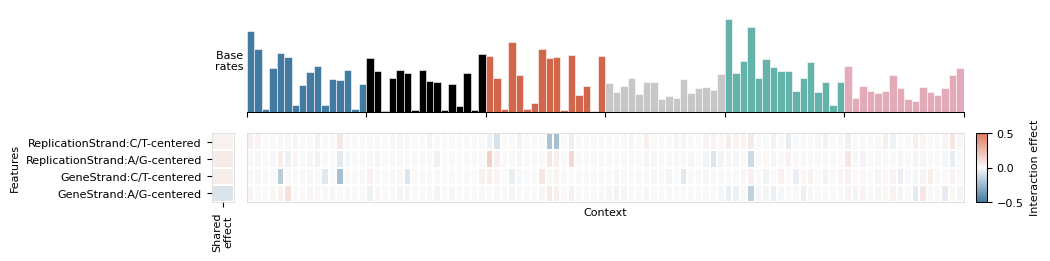

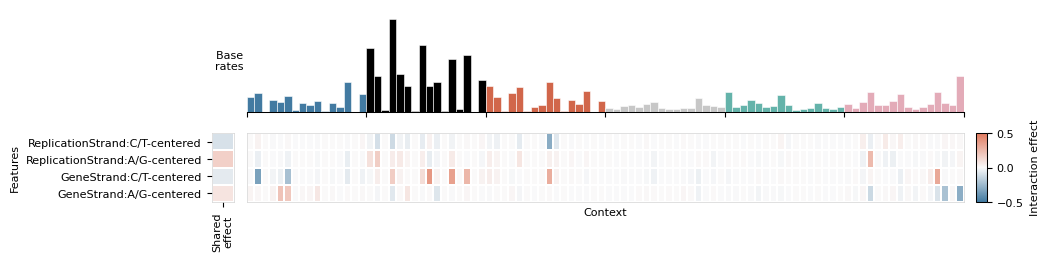

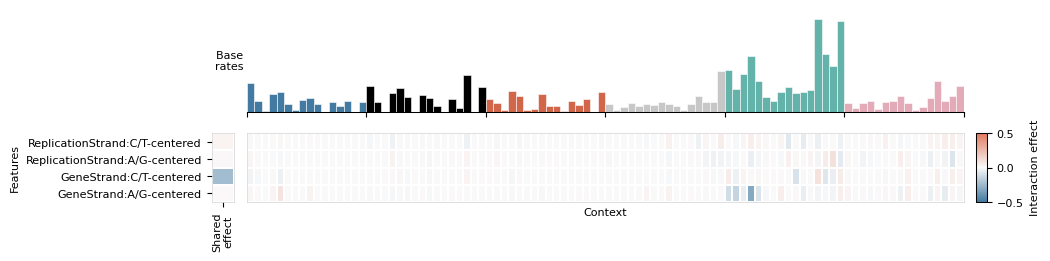

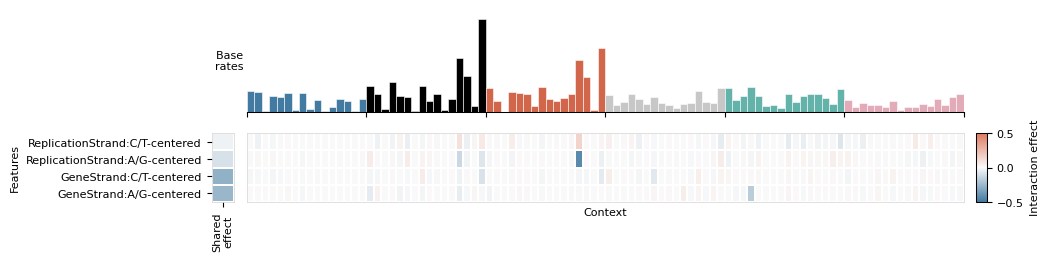

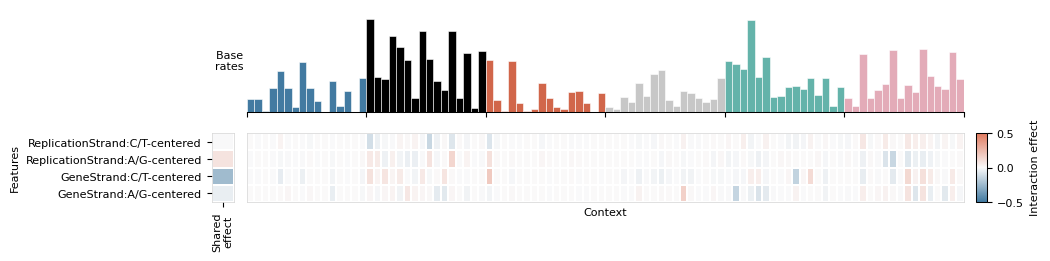

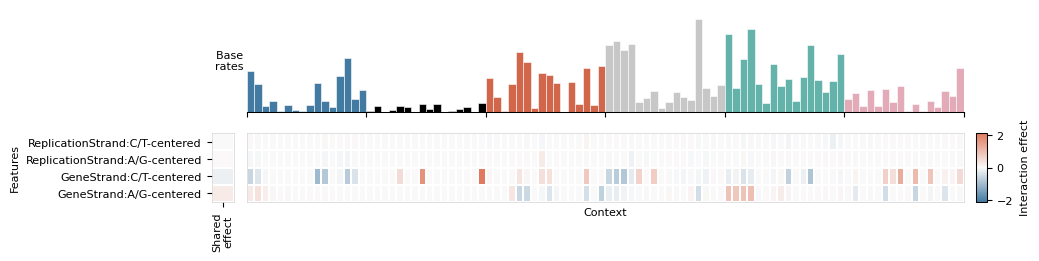

In [17]:
for component in mu.gt.list_components(data):
    mu.pl.plot_interaction_matrix(data, component)

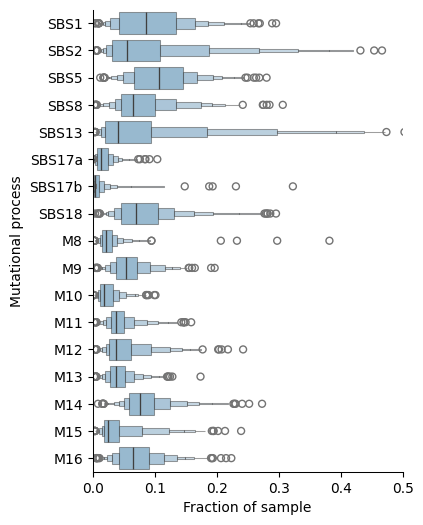

In [8]:
contribs = data["contributions"]
data["relative_contributions"] = contribs.squeeze()/contribs.squeeze().sum(dim="component")
_, ax = plt.subplots(figsize=(4,6))
sns.boxenplot(
    data["relative_contributions"].to_pandas().melt(ignore_index=False),
    x="value",
    y="component",
    alpha=0.5,
    ax = ax,
)
ax.set(xlim=(0,0.5), xlabel="Fraction of sample", ylabel="Mutational process")
sns.despine()

/n/data1/hms/dbmi/park/ctDNA_loci_project/locusregression/shared_envs/mutopia-official/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/n/data1/hms/dbmi/park/ctDNA_loci_project/locusregression/shared_envs/mutopia-official/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


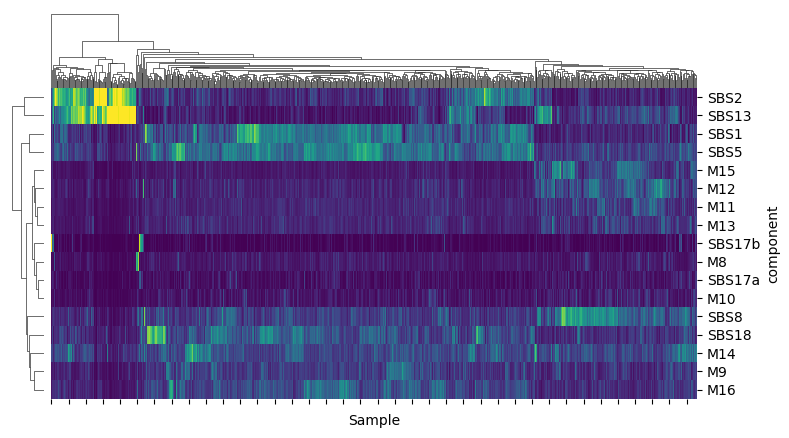

In [9]:
g = sns.clustermap(data["relative_contributions"].to_pandas().T, cbar_pos=None, figsize=(8,6), cmap="viridis", vmax=0.35, dendrogram_ratio=(0.05,0.2))
g.ax_heatmap.set_xlabel("Sample")
g.ax_heatmap.set_xticklabels([])
None

In [10]:
view = tr.make_view(data, "chr2:1000000-100000000")

INFO     Mutopia Found 12622/31651 regions matching query.


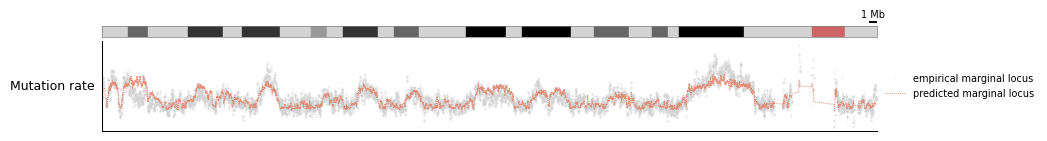

In [11]:
prediction_config = lambda view, scalebar_bp=1_000_000 : (
    tr.scale_bar(scalebar_bp, scale="mb" if scalebar_bp >= 1_000_000 else "kb"),
    tr.ideogram("annotations/hg38.cytoband.bed.gz"),
    tr.tracks.plot_marginal_observed_vs_expected(
        view,
        pred_smooth=7,
        smooth=7,
        height=1.25,
    ),
)

tr.plot_view(prediction_config, view, width=10)
None

/n/data1/hms/dbmi/park/allen_l/mutopia/Mutopia/mutopia/plot/track_plot/transforms.py:391: PerformanceWarning: indexing past lexsort depth may impact performance.
  df = topography_matrix.loc["C/T-centered", mutation_type]


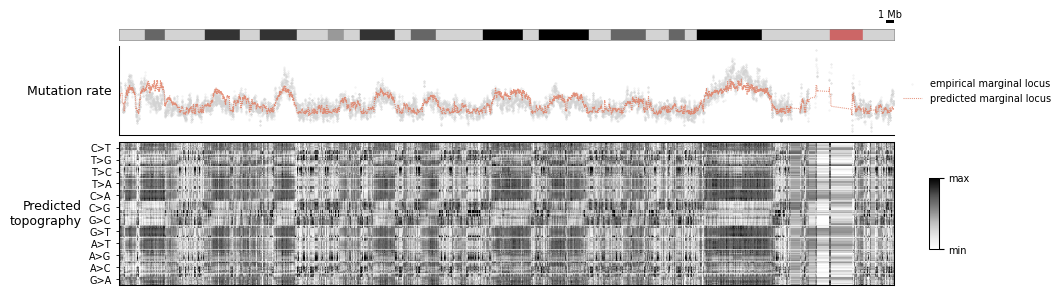

In [12]:
topography = tr.TopographyTransformer().fit(data)

topo_config = lambda view, scalebar_bp=1_000_000 : (
    prediction_config(view, scalebar_bp),
    tr.plot_topography(topography, height=2),
)
tr.plot_view(topo_config, view, width=10)
None

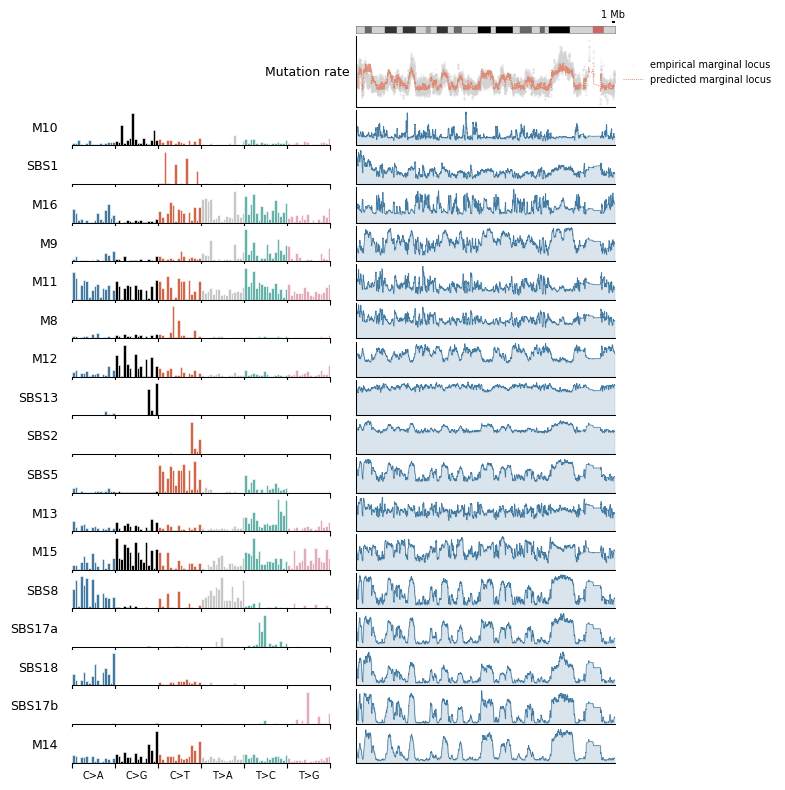

In [45]:
from functools import partial
def _plot_component(comp_name, ax):
    ax = mu.pl.plot_spectrum(mu.gt.fetch_component(data, comp_name).sel(genome_state="Baseline"), ax=ax)
    ax.set_ylabel(
        comp_name, fontsize=9, rotation=0, labelpad=10, va="center", ha="right"
    )
    return ax

components_config = lambda view, scalebar_bp=1_000_000 : (
    tr.columns(..., tr.scale_bar(scalebar_bp, scale="mb" if scalebar_bp >= 1_000_000 else "kb"), height=0.1,),
    tr.columns(..., tr.ideogram("annotations/hg38.cytoband.bed.gz"), height=0.1,),
    tr.columns(..., tr.tracks.plot_marginal_observed_vs_expected(
        view,
        pred_smooth=7,
        smooth=7,
        height=1.25,
    )),
    *[
        tr.columns(
            tr.custom_plot(partial(_plot_component, component)), 
            track, 
            height=0.5
        )
        for component in tr.order_components(data)
        for track in tr.plot_component_rates(view, component, label=" ")
    ]
)
tr.plot_view(components_config, view, width=7)
None